In [1]:
import pandas as pd
import numpy as np

import plotly.express as px
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

from sklearn.decomposition import PCA
from scipy.stats import qmc
from pymoo.problems import get_problem
from pymoo.core.problem import Problem
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting

from src.processing import calculate_fitness, find_pareto_front
from src.visualization import display_pareto_fronts3, plot_mmf1_dashboard, plot_landscapes_heatmap_dashboard


plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['lines.linewidth'] = 0.5

np.random.seed(42)

## Problemas MMF1, MMF4, BBOB16

In [2]:
class MMF1(Problem):
    """
    Implementação matemática EXATA do problema MMF1 (CEC 2019 MMOP).
    Possui duas regiões ótimas globais no espaço de decisão que espelham 
    em x1 = 2, formando uma ponta (descontinuidade da derivada).
    """
    def __init__(self):
        # Limites oficiais do MMF1: x1 em [1, 3], x2 em [-1, 1]
        super().__init__(n_var=2, n_obj=2, xl=np.array([1.0, -1.0]), xu=np.array([3.0, 1.0]))

    def _evaluate(self, X, out, *args, **kwargs):
        x1, x2 = X[:, 0], X[:, 1]
        
        # f1 mapeia [1, 3] para [0, 1] espelhando no 2
        f1 = np.abs(x1 - 2.0)
        
        # A senoide com período 1/3 (6*pi) e deslocamento de fase (pi)
        # que gera a ponta aguda (descontinuidade) em x1 = 2
        senoide = np.sin(6.0 * np.pi * np.abs(x1 - 2.0) + np.pi)
        
        # f2 penaliza qualquer desvio da senoide
        f2 = 1.0 - np.sqrt(f1) + 2.0 * (x2 - senoide)**2
        
        out["F"] = np.column_stack([f1, f2])

In [3]:
class MMF4(Problem):
    """
    Problema MMF4 (Niching Simétrico).
    Forte não-linearidade com 4 conjuntos de Pareto globais no espaço de decisão 
    (formando perfeitamente dois 'M's empilhados, como o logo do McDonald's).
    """
    def __init__(self):
        # Limites: x1 de -1 a 1 | x2 de 0 a 2
        super().__init__(n_var=2, n_obj=2, xl=np.array([-1.0, 0.0]), xu=np.array([1.0, 2.0]))

    def _evaluate(self, X, out, *args, **kwargs):
        x1, x2 = X[:, 0], X[:, 1]
        
        # Equações exatas do MMF4 com a periodicidade corrigida!
        f1 = np.abs(x1)
        
        # O uso do sin(pi * (...)) cria as raízes múltiplas.
        # Raiz 1: x2 = sin(pi*|x1|)       -> O "M" de baixo (0 a 1)
        # Raiz 2: x2 = 1 + sin(pi*|x1|)   -> O "M" de cima (1 a 2)
        f2 = 1.0 - x1**2 + 2.0 * np.sin(np.pi * (x2 - np.sin(np.pi * np.abs(x1))))**2
        
        out["F"] = np.column_stack([f1, f2])

In [4]:
class BBOB_Gallagher_Mock(Problem):
    """
    Recriação matemática do BBOB f16 (Gallagher's 101 Peaks).
    Gera uma superfície caótica com 101 crateras gaussianas para cada objetivo.
    """
    def __init__(self, n_peaks=101):
        super().__init__(n_var=2, n_obj=2, xl=np.array([-5.0, -5.0]), xu=np.array([5.0, 5.0]))
        self.n_peaks = n_peaks
        
        np.random.seed(42) # Seed fixa para o terreno ser igual na sua dissertação
        
        # Parâmetros das 101 crateras
        self.c1 = np.random.uniform(-4.5, 4.5, (n_peaks, 2))
        self.w1 = np.random.uniform(0.1, 2.0, n_peaks)
        self.s1 = np.random.uniform(0.2, 1.0, n_peaks)
        
        self.c2 = np.random.uniform(-4.5, 4.5, (n_peaks, 2))
        self.w2 = np.random.uniform(0.1, 2.0, n_peaks)
        self.s2 = np.random.uniform(0.2, 1.0, n_peaks)

    def _evaluate(self, X, out, *args, **kwargs):
        f1 = np.zeros(X.shape[0])
        f2 = np.zeros(X.shape[0])
        
        for i in range(self.n_peaks):
            dist1 = np.sum((X - self.c1[i])**2, axis=1)
            f1 -= self.w1[i] * np.exp(-dist1 / (2 * self.s1[i]**2))
            
            dist2 = np.sum((X - self.c2[i])**2, axis=1)
            f2 -= self.w2[i] * np.exp(-dist2 / (2 * self.s2[i]**2))
            
        f1 = f1 - np.min(f1) + 0.1
        f2 = f2 - np.min(f2) + 0.1
        
        out["F"] = np.column_stack([f1, f2])

## Gerando DataFrames

In [5]:
def generate_problem_dataframe(problem, n_observations=100_000):

    n_points = int(np.sqrt(n_observations))

    x1 = np.linspace(problem.xl[0], problem.xu[0], n_points)
    x2 = np.linspace(problem.xl[1], problem.xu[1], n_points)
    X1, X2 = np.meshgrid(x1, x2)
    
    X_flat = np.column_stack([X1.ravel(), X2.ravel()])
    
    out = {}
    problem._evaluate(X_flat, out)
    F_flat = out["F"]
    
    # Montando o DataFrame principal
    df = pd.DataFrame(X_flat, columns=['x_1', 'x_2'])
    df['f1'] = F_flat[:, 0]
    df['f2'] = F_flat[:, 1]
    
    # Extraindo o Pareto Verdadeiro
#    nds = NonDominatedSorting()
#    fronts = nds.do(F_flat)
#    pareto_idx = fronts[0] 
#    
#    df_pareto = df.iloc[pareto_idx].copy()
#    df_pareto = df_pareto.sort_values(by='f1') 
    
    return df#, df_pareto

In [6]:
# Inicializando os problemas
mmf1 = MMF1()
mmf4 = MMF4()
bbob = BBOB_Gallagher_Mock()

# Gerando DataFrames
df_mmf1   = generate_problem_dataframe(mmf1, n_observations=1_000_000)
df_mmf4   = generate_problem_dataframe(mmf4, n_observations=1_000_000)
df_bbob16 = generate_problem_dataframe(bbob, n_observations=1_000_000)

df_mmf1['aux']   = 1
df_mmf4['aux']   = 1
df_bbob16['aux'] = 1

In [7]:
plot_heatmaps = False

################################################################
################################################## overview MMF1
display(df_mmf1.head())

if plot_heatmaps:
    display(px.density_heatmap(df_mmf1, x='x_1', y='x_2', z='aux', 
                            histfunc='sum', # Pode ser 'sum', 'min', 'max'
                            nbinsx=100, nbinsy=100, # Quantidade de quadradinhos
                            title='Espaço de Decisão - Heatmap de Densidade'))

# Salvando resultados
df_mmf1.to_parquet('data/dataframes/MMF1/df_mmf1.parquet')



################################################################
################################################## overview MMF4
display(df_mmf4.head())

if plot_heatmaps:
    display(px.density_heatmap(df_mmf4, x='x_1', y='x_2', z='aux', 
                            histfunc='sum', # Pode ser 'sum', 'min', 'max'
                            nbinsx=100, nbinsy=100, # Quantidade de quadradinhos
                            title='Espaço de Decisão - Heatmap de Densidade'))

# Salvando resultados
df_mmf4.to_parquet('data/dataframes/MMF4/df_mmf4.parquet')



################################################################
################################################ overview BBOB16
display(df_bbob16.head())

if plot_heatmaps:
    display(px.density_heatmap(df_bbob16, x='x_1', y='x_2', z='aux', 
                            histfunc='sum', # Pode ser 'sum', 'min', 'max'
                            nbinsx=100, nbinsy=100, # Quantidade de quadradinhos
                            title='Espaço de Decisão - Heatmap de Densidade'))

# Salvando resultados
df_bbob16.to_parquet('data/dataframes/BBOB16/df_bbob16.parquet')

,x_1,x_2,f1,f2,aux
0,1.000000,-1.0,1.000000,2.000000,1
1,1.002002,-1.0,0.997998,2.154760,1
2,1.004004,-1.0,0.995996,2.314983,1
3,1.006006,-1.0,0.993994,2.480407,1
4,1.008008,-1.0,0.991992,2.650737,1


,x_1,x_2,f1,f2,aux
0,-1.000000,0.0,1.000000,2.960407e-31,1
1,-0.997998,0.0,0.997998,4.780718e-03,1
2,-0.995996,0.0,0.995996,1.111352e-02,1
3,-0.993994,0.0,0.993994,1.899438e-02,1
4,-0.991992,0.0,0.991992,2.841661e-02,1


,x_1,x_2,f1,f2,aux
0,-5.00000,-5.0,8.666895,5.831873,1
1,-4.98999,-5.0,8.665178,5.826707,1
2,-4.97998,-5.0,8.663448,5.821392,1
3,-4.96997,-5.0,8.661705,5.815924,1
4,-4.95996,-5.0,8.659949,5.810299,1


## Encontrando o front de Pareto ótimo

In [8]:
df_pareto_mmf1   = find_pareto_front(df_mmf1,   minimize=True, fitness1='f1', fitness2='f2')
df_pareto_mmf4   = find_pareto_front(df_mmf4,   minimize=True, fitness1='f1', fitness2='f2')
df_pareto_bbob16 = find_pareto_front(df_bbob16, minimize=True, fitness1='f1', fitness2='f2')

Encontrando fronteira de Pareto (algoritmo otimizado)...
Total de pontos no espaço de busca: 1,000,000
✅ Fronteira de Pareto encontrada!
Fronteira de Pareto contém 1,000 pontos.
Isso representa 0.1000% do espaço de busca.
Encontrando fronteira de Pareto (algoritmo otimizado)...
Total de pontos no espaço de busca: 1,000,000
✅ Fronteira de Pareto encontrada!
Fronteira de Pareto contém 1,019 pontos.
Isso representa 0.1019% do espaço de busca.
Encontrando fronteira de Pareto (algoritmo otimizado)...
Total de pontos no espaço de busca: 1,000,000
✅ Fronteira de Pareto encontrada!
Fronteira de Pareto contém 719 pontos.
Isso representa 0.0719% do espaço de busca.


## Análise visual

/Users/gmello/Documents/python_repos/mestrado/ua-dd-saea/src/visualization.py:1644: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


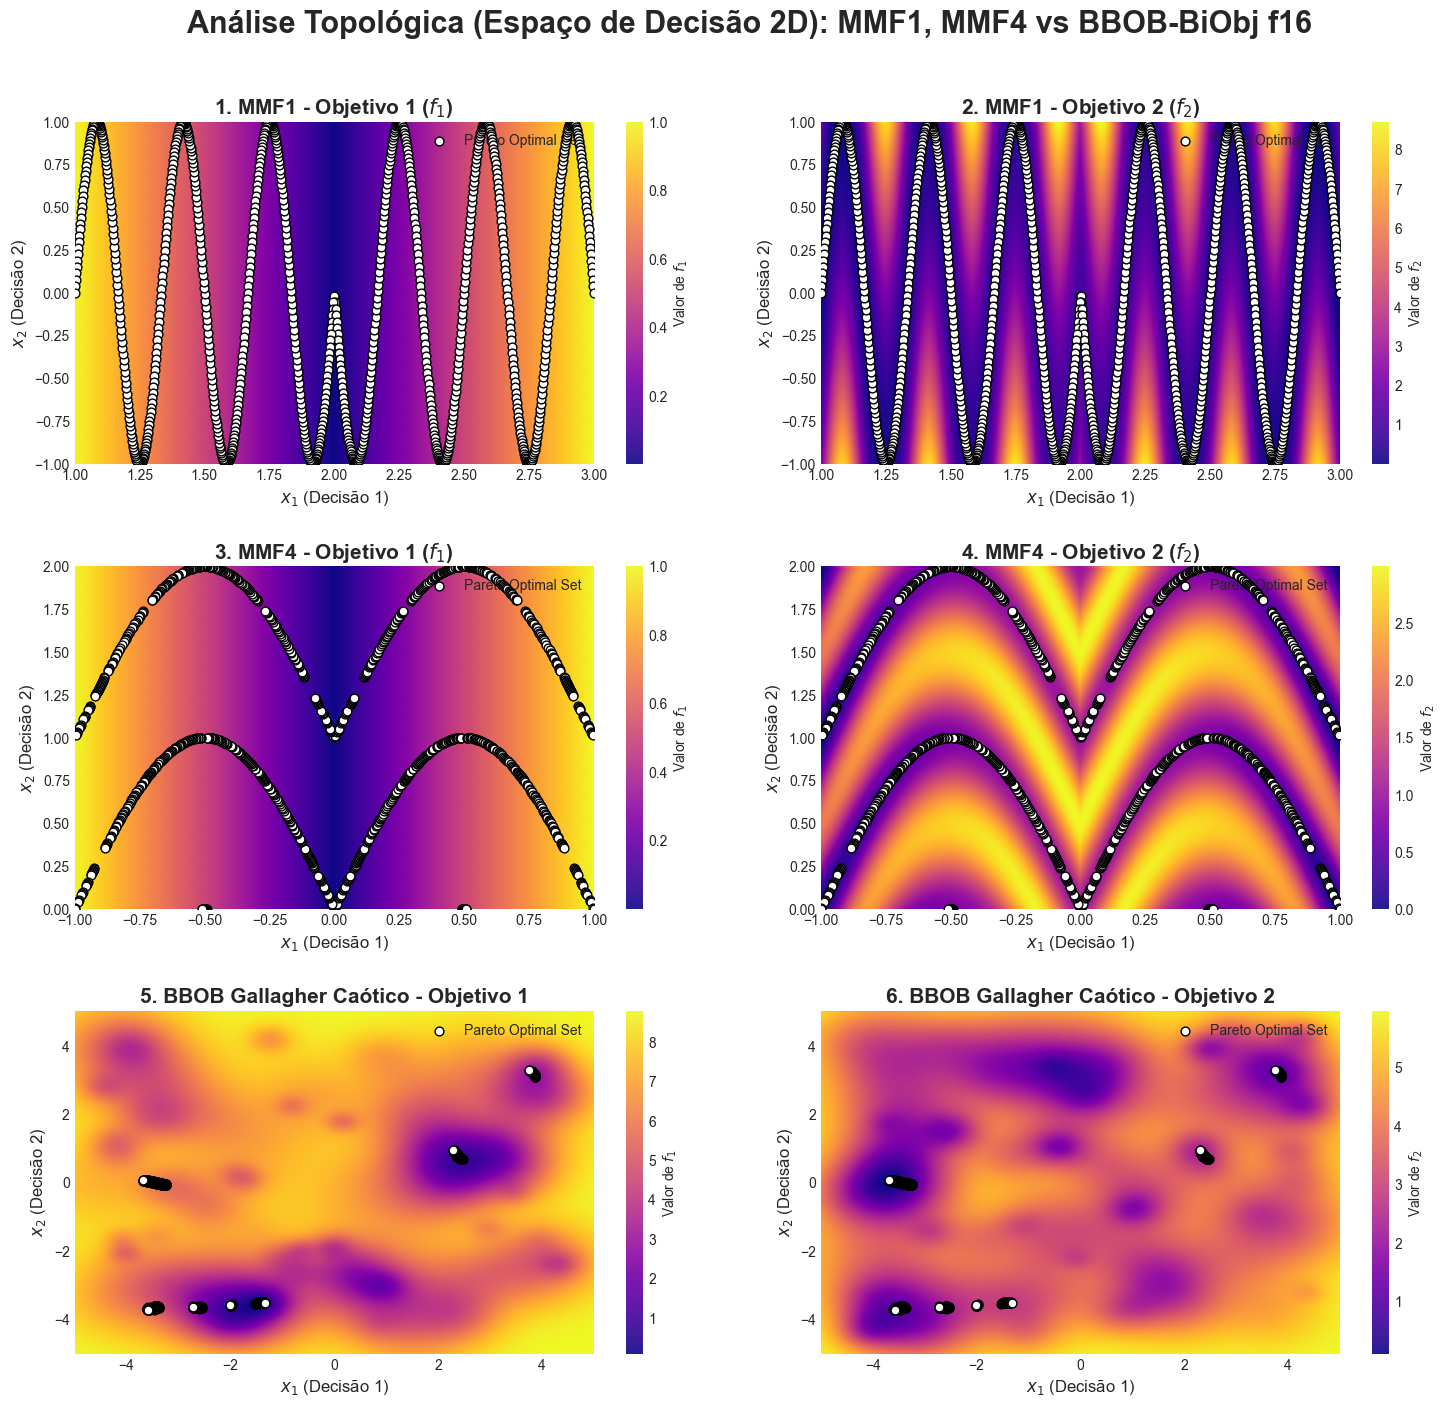

In [9]:
plot_landscapes_heatmap_dashboard(
    df_mmf1, df_pareto_mmf1, mmf1,     # MMF1
    df_mmf4, df_pareto_mmf4, mmf4,     # MMF4
    df_bbob16, df_pareto_bbob16, bbob  # BBOB
)

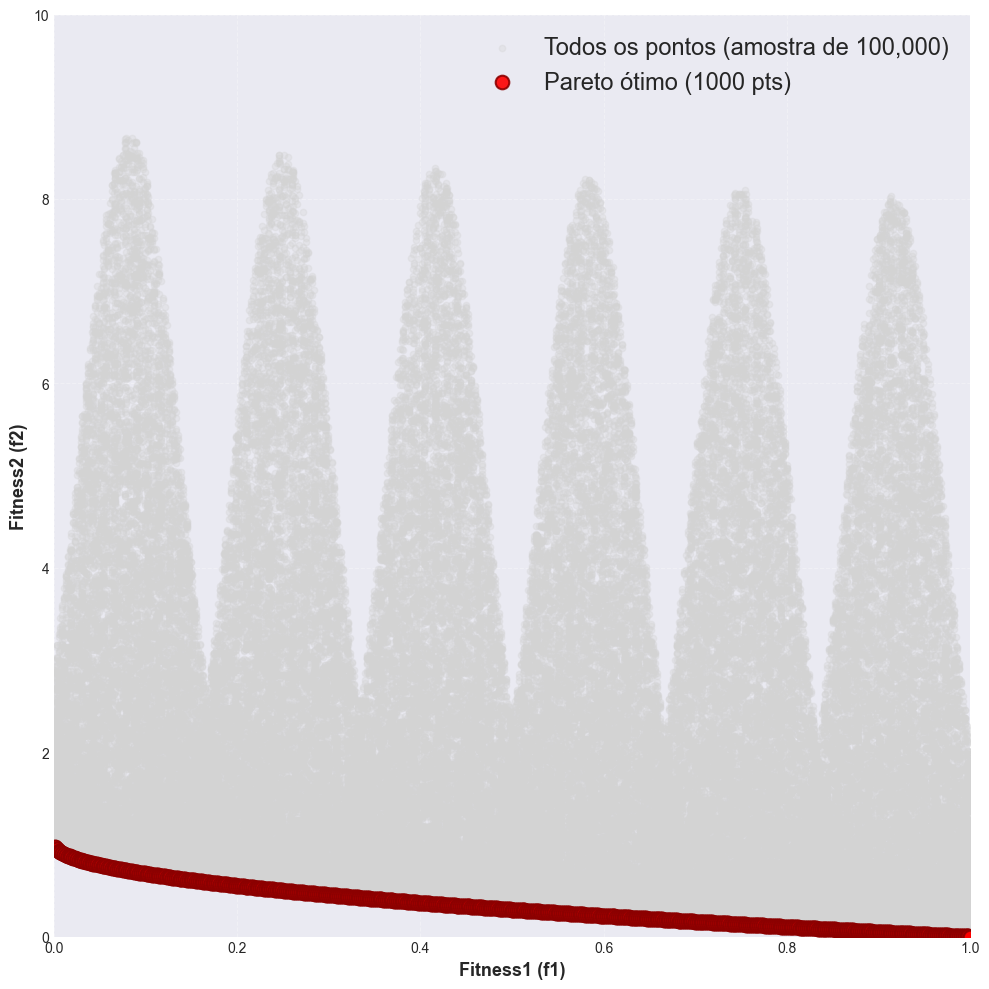

In [10]:
# Plota fronteira de Pareto real
fig_front = display_pareto_fronts3(df_mmf1, 
                                  [df_pareto_mmf1], 
                                   fitness1='f1', fitness2='f2', 
                                   front_names=['Pareto ótimo'], 
                                   sample_size=100_000)
#fig_front.savefig('data/figures/nb1_front_verdadeiro_problema1.jpg', dpi=150, bbox_inches='tight')

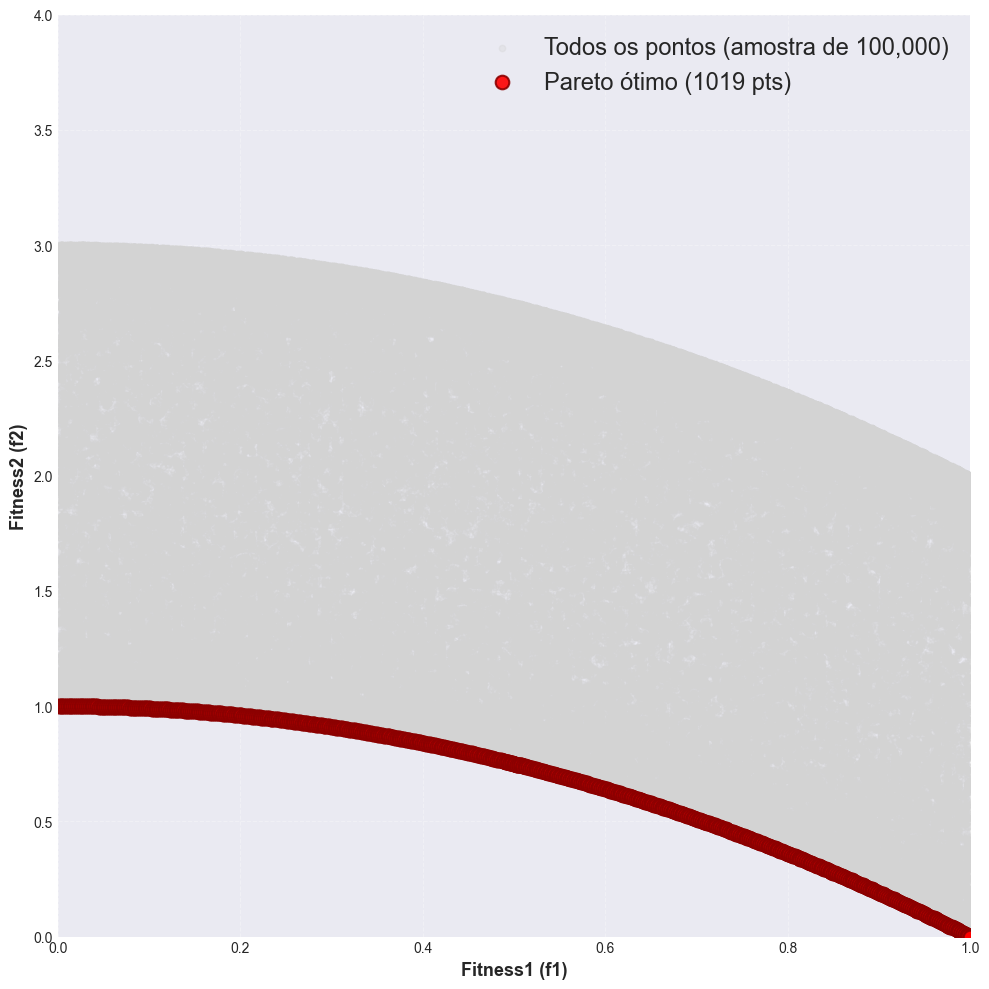

In [11]:
# Plota fronteira de Pareto real
fig_front = display_pareto_fronts3(df_mmf4, 
                                  [df_pareto_mmf4], 
                                   fitness1='f1', fitness2='f2', 
                                   front_names=['Pareto ótimo'], 
                                   sample_size=100_000)
#fig_front.savefig('data/figures/nb1_front_verdadeiro_problema1.jpg', dpi=150, bbox_inches='tight')

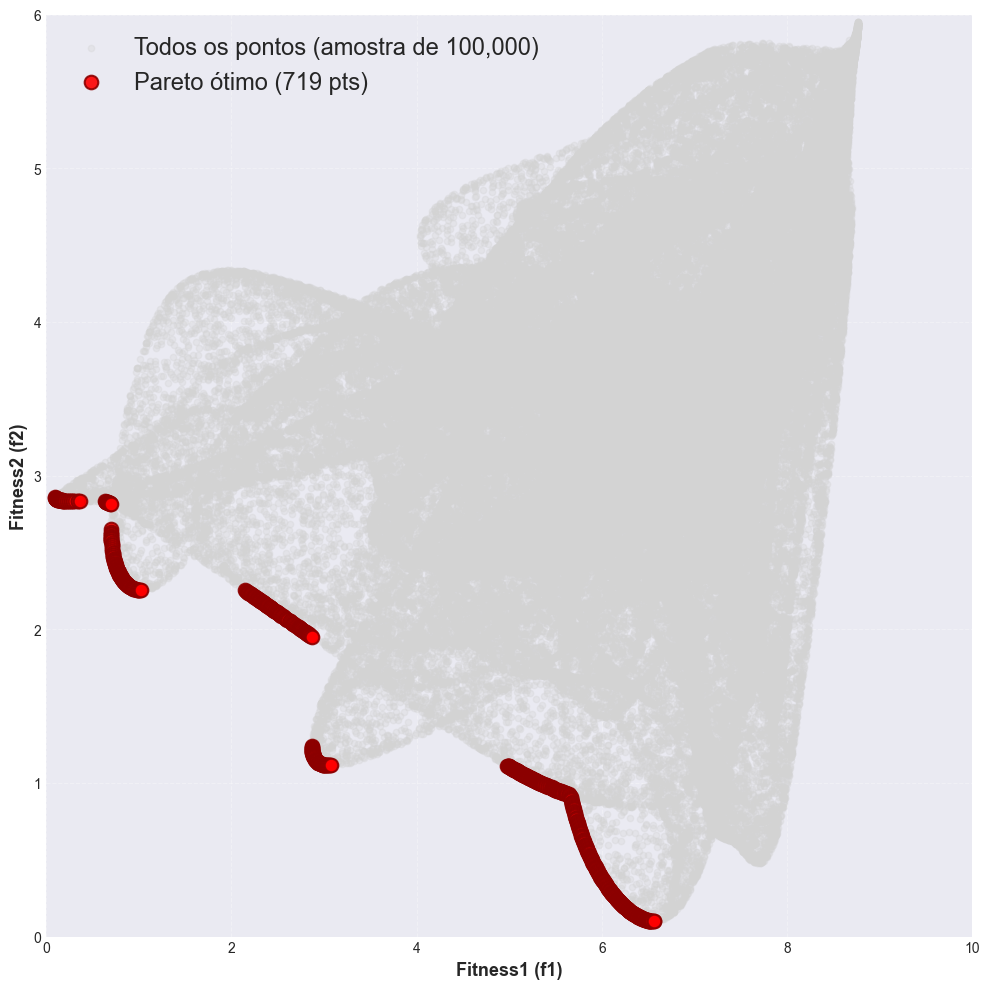

In [12]:
# Plota fronteira de Pareto real
fig_front = display_pareto_fronts3(df_bbob16, 
                                  [df_pareto_bbob16], 
                                   fitness1='f1', fitness2='f2', 
                                   front_names=['Pareto ótimo'], 
                                   sample_size=100_000)
#fig_front.savefig('data/figures/nb1_front_verdadeiro_problema1.jpg', dpi=150, bbox_inches='tight')

# Analise visual 2

In [13]:
#plot_mmf1_dashboard(df_mmf1, df_pareto_mmf1, features_cols=['x_1', 'x_2'])
#plot_mmf1_dashboard(df_mmf4, df_pareto_mmf4, features_cols=['x_1', 'x_2'])
#plot_mmf1_dashboard(df_bbob16, df_pareto_bbob16, features_cols=['x_1', 'x_2'])

# ZDT1

In [14]:
# ==========================================================
# 2. FUNÇÃO DE GERAÇÃO COM SOBOL ATUALIZADA
# ==========================================================
def generate_mmf1_sobol(obs=1_000_000):
    """
    Gera um dataset contínuo para o problema MMF1 usando a Sequência de Sobol.
    Escalona automaticamente os dados para os limites reais do problema.
    """
    print(f"Iniciando a geração de {obs:,} amostras para o MMF1 (Sobol)...")
    
    # 1. Instancia nossa classe customizada do MMF1
    problem = MMF1()
    n_vars = problem.n_var
    xl = problem.xl  # [1.0, -1.0]
    xu = problem.xu  # [3.0,  1.0]
    
    # 2. Instancia o gerador de Sobol
    sampler = qmc.Sobol(d=n_vars, scramble=True)
    X_raw = sampler.random(n=obs) # Valores puros entre 0 e 1
    
    # 3. Transforma (Escalona) os valores para os limites reais do MMF1
    X = xl + X_raw * (xu - xl)
    
    # 4. Avalia as amostras (agora usando a nossa classe)
    print("Avaliando as funções objetivo...")
    # O PyMOO exige que passemos um dicionário 'out' para capturar os resultados
    out = {}
    problem._evaluate(X, out)
    F = out["F"]
    
    # 5. Constrói o DataFrame
    df = pd.DataFrame(X, columns=['x_1', 'x_2'])
    df['f1'] = F[:, 0]
    df['f2'] = F[:, 1]
    
    # 6. Ordenação Topológica para visualização contínua (Registro)
    print("Aplicando PCA para extração do registro espacial...")
    pca = PCA(n_components=1)
    df['pca_1'] = pca.fit_transform(X)
    df = df.sort_values(by='pca_1').reset_index(drop=True)
    df.drop(columns=['pca_1'], inplace=True)
    df['registro'] = df.index
    
    print(f"✅ Base MMF1 gerada com sucesso! Memória: {df.memory_usage().sum() / 1e6:.2f} MB")
    
    return df

# ==========================================================
# Execução
# ==========================================================
#df_mmf1 = generate_mmf1_sobol(obs=1_000_000)

In [15]:
def generate_zdt1_smooth_space(obs):

    """
    Gera um dataset contínuo para o problema ZDT1 usando a Sequência de Sobol + Escala Uniforme.
    Para combater a Concentração de Medida, criamos uma ponte contínua de soluções desde a nuvem 
    de alta dimensão até encostar exatamente no Front de Pareto Verdadeiro.

    Ordenação topológica: Utiliza PCA para reduzir as 30 dimensões em 1, e ordena o DataFrame 
    seguindo a "linha" desse componente principal.
    -----------
    
    Parâmetros:
    -----------
    obs : int
        Número de observações (linhas) que a base de dados terá.
        
    Retorno:
    --------
    pd.DataFrame
        DataFrame contendo as 30 variáveis de decisão (x_1 a x_30), 
        as funções objetivo (f1 e f2) 
        e a coluna de ordenação topológica (registro).
    """

    n_vars = 30
    print(f"Gerando {obs:,} amostras contínuas (Sobol + Escala Uniforme)...")
    
    # Gera a matriz de solucoes X original via gerador de Sobol
    sampler = qmc.Sobol(d=n_vars, scramble=True)
    X = sampler.random(n=obs)


    ### Garantindo amostragem no front verdadeiro, e amostragem uniformemente distante do front
    # 99% das soluções de ZDT1 estão longe do front verdadeiro (onde x2,x3,...,x30 = 0)
    # para garantir que a amostra cubra esse front e o caminho até ele, vamos adicionar um fator de escala nas variáveis x2,x3,...,x30
    alpha = np.linspace(0.0, 1.0, obs)
    np.random.shuffle(alpha)

    for i in range(1, n_vars):
        X[:, i] = X[:, i] * alpha


    # Avalia as soluções do problema ZDT1
    problem = get_problem("zdt1", n_var=n_vars)
    F = problem.evaluate(X)
    
    # Constrói o DataFrame das variáveis de entrada
    col_names = [f'x_{i+1}' for i in range(n_vars)]
    df = pd.DataFrame(X, columns=col_names)
    
    df['f1'] = F[:, 0]
    df['f2'] = F[:, 1]


    # Ordenação topologica: utiliza PCA para condensar 30 dimensões em 1
    pca = PCA(n_components=1)
    df['pca_1'] = pca.fit_transform(X)

    df = df.sort_values(by='pca_1').reset_index(drop=True)
    df = df.drop(columns=['pca_1'])
    df['registro'] = df.index
    df['aux'] = 1
    
    print(f"✅ Geração concluída com sucesso!")
    

    return df


# ==========================================================
# Executando a função
# ==========================================================
    
#df_zdt1 = generate_zdt1_smooth_space(obs=1_000_000)
#display(df_zdt1.head())
#
## Salvando resultados
#df_zdt1.to_parquet('data/dataframes/ZDT1/df_zdt1.parquet')

In [16]:
def plot_zdt1_variable_pairs_grid(df, color_col='f1', agg_func='mean', gridsize=40, cmap='plasma'):
    """
    Gera um grid 4x4 de heatmaps hexagonais para os pares de variáveis do ZDT1.
    
    Parâmetros:
    -----------
    df : pd.DataFrame
        O dataframe contendo as variáveis e a coluna alvo.
    color_col : str
        O nome da coluna que definirá a cor (ex: 'f1', 'registro' ou uma coluna de 1s para contagem).
    agg_func : str
        'mean' para calcular a média da região, ou 'sum' para somar os valores na região.
    gridsize : int
        A resolução do heatmap (quantidade de hexágonos).
    cmap : str
        A paleta de cores.
    """
    
    # 1. Define a função do numpy baseada no parâmetro
    if agg_func.lower() == 'sum':
        reduce_f = np.sum
        titulo_agg = 'Soma'
    else:
        reduce_f = np.mean
        titulo_agg = 'Média'

    # Cria o grid 4x4
    fig, axes = plt.subplots(4, 4, figsize=(20, 18))
    fig.suptitle(f'Visão em Pares das Variáveis ZDT1\nColorido pela {titulo_agg} de: {color_col}', 
                 fontsize=22, fontweight='bold', y=0.96)
    
    axes = axes.flatten()
    
    # Lista para guardar os objetos gerados e depois sincronizar as cores
    hexbins = []
    
    # ==========================================================
    # GERAÇÃO DOS 15 GRÁFICOS (Sem fixar a cor ainda)
    # ==========================================================
    for i in range(15):
        x_col = f'x_{2*i + 1}'
        y_col = f'x_{2*i + 2}'
        ax = axes[i]
        
        # Gera o heatmap (Omitimos vmin e vmax aqui para deixar ele calcular livremente primeiro)
        hb = ax.hexbin(df[x_col], df[y_col], C=df[color_col], 
                       reduce_C_function=reduce_f, gridsize=gridsize, 
                       cmap=cmap, mincnt=1, edgecolors='none')
        hexbins.append(hb)
        
        ax.set_title(f'{x_col} vs {y_col}', fontsize=14, fontweight='bold')
        ax.set_xlabel(x_col, fontsize=11)
        ax.set_ylabel(y_col, fontsize=11)
        
        ax.set_xlim(df[x_col].min(), df[x_col].max())
        ax.set_ylim(df[y_col].min(), df[y_col].max())

    # ==========================================================
    # SINCRONIZAÇÃO DA ESCALA DE CORES GLOBAL
    # ==========================================================
    # Descobre o valor real mínimo e máximo resultante dos hexágonos em todos os gráficos
    vmin_global = min([hb.get_array().min() for hb in hexbins if len(hb.get_array()) > 0])
    vmax_global = max([hb.get_array().max() for hb in hexbins if len(hb.get_array()) > 0])
    
    # Aplica essa escala global para todos os 15 gráficos
    for hb in hexbins:
        hb.set_clim(vmin_global, vmax_global)

    # ==========================================================
    # 16º ESPAÇO: BARRA DE CORES EMBUTIDA
    # ==========================================================
    ax_cbar = axes[15]
    ax_cbar.axis('off') # Remove bordas e eixos da 16ª posição
    
    # Cria um eixo "filho" dentro da posição 15 (Esquerda, Base, Largura, Altura em proporção 0 a 1)
    # Isso deixa a barra bem centralizada e pequenininha
    cax = ax_cbar.inset_axes([0.35, 0.1, 0.2, 0.8])
    
    # Desenha a barra de cores usando a escala do primeiro gráfico (que já foi sincronizado)
    cbar = fig.colorbar(hexbins[0], cax=cax, orientation='vertical')
    cbar.set_label(f'{titulo_agg} de {color_col}', fontsize=14, fontweight='bold')
    
    # Define os 3 marcadores exatos: Fundo, Meio e Topo
    meio = (vmin_global + vmax_global) / 2
    cbar.set_ticks([vmin_global, meio, vmax_global])
    
    # Formatação dos textos para ficar limpo (inteiros se for Soma, decimais se for Média)
    if agg_func.lower() == 'sum':
        cbar.ax.set_yticklabels([f'{int(vmin_global)}', f'{int(meio)}', f'{int(vmax_global)}'])
    else:
        cbar.ax.set_yticklabels([f'{vmin_global:.3f}', f'{meio:.3f}', f'{vmax_global:.3f}'])

    plt.tight_layout()
    plt.subplots_adjust(top=0.92) 
    plt.show()

# ==========================================================
# Exemplo de Uso:
# ==========================================================
# 2. Se quiser contar a DENSIDADE (Cobertura da Amostragem):
# Primeiro você cria uma coluna temporária valendo 1 para cada linha do DataFrame:
# df_zdt1['contador'] = 1
#plot_zdt1_variable_pairs_grid(df_zdt1, color_col='aux', agg_func='sum', gridsize=40)

### Análise visual dos resultados

In [17]:
## Plota fronteira de Pareto real
#df_pareto_zdt1 = find_pareto_front(df_zdt1, minimize=True, fitness1='f1', fitness2='f2')
#fig_front = display_pareto_fronts3(df_zdt1, [df_pareto_zdt1], fitness1='f1', fitness2='f2', front_names=['Fronteira de Pareto Real'], sample_size=1_000_000)
##fig_front.savefig('data/figures/nb1_front_verdadeiro_problema1.jpg', dpi=150, bbox_inches='tight')

In [18]:
def plot_zdt1_dashboard_with_pareto(df, pareto_df, features_cols, fit1_col='f1', fit2_col='f2'):
    """
    Gera um dashboard com 4 visualizações clássicas para problemas de alta dimensão.
    Mantém as figuras 2, 3, 4 e 5 originais organizadas em um grid 2x2.
    """
    # Configuração geral da figura com GridSpec para layout 2x2
    fig = plt.figure(figsize=(20, 14))
    plt.style.use('seaborn-v0_8-darkgrid')
    
    # Título principal removido conforme solicitado
    
    # Grid de 2 linhas e 2 colunas
    gs = GridSpec(2, 2, figure=fig, hspace=0.30, wspace=0.15)
    
    # Cores baseadas na "qualidade" da solução no df original
    c_values_df = df[fit1_col] + df[fit2_col]
    
    # ==========================================================
    # 2. Fatiamento 3D do Espaço (Slicing x1 e x2) -> Agora no topo-esquerdo
    # ==========================================================
    ax2 = fig.add_subplot(gs[0, 0], projection='3d')
    
    x1_vals = np.linspace(0, 1, 100)
    x2_vals = np.linspace(0, 1, 100)
    X1, X2 = np.meshgrid(x1_vals, x2_vals)
    G = 1.0 + (9.0 / 29.0) * X2
    F2 = G * (1.0 - np.sqrt(X1 / G))
    
    surf = ax2.plot_surface(X1, X2, F2, cmap='plasma', alpha=0.8, antialiased=True)
    
    ax2.set_title('2. Fatiamento 3D (Variando $x_1$ e $x_2$, Resto = 0)', fontsize=15, fontweight='bold')
    ax2.set_xlabel('$x_1$ (Controla $f_1$)', fontsize=12)
    ax2.set_ylabel('$x_2$ (Penalidade de $g$)', fontsize=12)
    ax2.set_zlabel(f'Fitness 2 (${fit2_col}$)', fontsize=12)
    ax2.view_init(elev=25, azim=45)
    fig.colorbar(surf, ax=ax2, shrink=0.5, aspect=10, label=f'Fitness 2 (${fit2_col}$)')

    # ==========================================================
    # 3. Redução de Dimensionalidade (PCA) -> Agora no topo-direito
    # ==========================================================
    ax3 = fig.add_subplot(gs[0, 1])
    
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(df[features_cols])
    var_exp = pca.explained_variance_ratio_ * 100
    
    scatter3 = ax3.scatter(X_pca[:, 0], X_pca[:, 1], 
                           c=c_values_df, cmap='viridis', 
                           alpha=0.4, s=10, edgecolor='none')
    
    ax3.set_title('3. Espaço de Decisão Reduzido (PCA - População Geral)', fontsize=15, fontweight='bold')
    ax3.set_xlabel(f'Componente 1 ({var_exp[0]:.1f}% da variância)', fontsize=12)
    ax3.set_ylabel(f'Componente 2 ({var_exp[1]:.1f}% da variância)', fontsize=12)
    fig.colorbar(scatter3, ax=ax3, label='Qualidade da Solução ($f_1 + f_2$)')

    # ==========================================================
    # PREPARANDO DADOS DO PARETO (Para Gráficos 4 e 5)
    # ==========================================================
    if len(pareto_df) > 100:
        pareto_plot = pareto_df.sample(100, random_state=42).copy()
    else:
        pareto_plot = pareto_df.copy()
        
    pareto_plot = pareto_plot.sort_values(by=fit1_col)

    # ==========================================================
    # 4. Coordenadas Paralelas (PARETO FRONT) -> Agora no canto inferior-esquerdo
    # ==========================================================
    ax4 = fig.add_subplot(gs[1, 0])
    
    norm = Normalize(vmin=pareto_plot[fit1_col].min(), vmax=pareto_plot[fit1_col].max())
    cmap = plt.get_cmap('cool')
    
    for _, row in pareto_plot.iterrows():
        color = cmap(norm(row[fit1_col]))
        ax4.plot(range(len(features_cols)), row[features_cols], color=color, alpha=0.7, linewidth=1.5)
    
    ax4.set_title(f'4. Coordenadas Paralelas (Front de Pareto - {len(pareto_plot)} Soluções)', fontsize=15, fontweight='bold')
    ax4.set_xticks(range(len(features_cols)))
    ax4.set_xticklabels(features_cols, rotation=90, fontsize=9)
    ax4.set_ylabel('Valor da Variável (0 a 1)', fontsize=12)
    ax4.set_ylim(-0.05, 1.05)
    
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax4, label=f'Fitness 1 (${fit1_col}$)')

    # ==========================================================
    # 5. Boxplot de Distribuição de Variáveis -> Agora no canto inferior-direito
    # ==========================================================
    ax5 = fig.add_subplot(gs[1, 1])
    
    box = ax5.boxplot(pareto_plot[features_cols].values, patch_artist=True,
                      boxprops=dict(facecolor='lightblue', color='navy', alpha=0.7, linewidth=1.5),
                      medianprops=dict(color='red', linewidth=2),
                      whiskerprops=dict(color='navy', linewidth=1.5),
                      capprops=dict(color='navy', linewidth=1.5),
                      flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.5))
    
    ax5.set_title(f'5. Distribuição Espacial no Front de Pareto (Boxplot)', fontsize=15, fontweight='bold')
    
    ax5.set_xticks(range(1, len(features_cols) + 1))
    ax5.set_xticklabels(features_cols, rotation=45, ha='right', fontsize=10)
    ax5.set_ylabel('Valor da Variável (0 a 1)', fontsize=12)
    ax5.set_ylim(-0.05, 1.05)
    
    ax5.grid(True, axis='y', alpha=0.5, linestyle='--')

    # TRUQUE PARA IGUALAR LARGURAS: Adiciona colorbar invisível no ax5 baseada no ax3
    cbar5 = fig.colorbar(scatter3, ax=ax5)
    cbar5.ax.set_visible(False)

    plt.tight_layout()
    plt.show()

# ==========================================================
# Como chamar a função no seu notebook:
# ==========================================================
#features = [f'x_{i+1}' for i in range(30)]
#plot_zdt1_dashboard_with_pareto(df_zdt1, df_pareto_zdt1, features, fit1_col='f1', fit2_col='f2')
#
############################################################
## funcao anterior
#plot_zdt1_variable_pairs_grid(df_zdt1, color_col='f2', agg_func='mean', gridsize=40)